# 1. Environment Setup & Package Configuration

## Purpose
This notebook sets up the production-grade Bayesian Media Mix Model (MMM) for Project **Titan**—a single-rooftop Chrysler/Jeep dealership operating across 104 weeks of historical data (`2024-08-05` to `2026-07-27`).

## Core Stack
* **Data Manipulation**: `numpy`, `pandas`, `scipy.stats`
* **Bayesian Inference Engine**: `pymc` (v5+), `pytensor`
* **MCMC Diagnostics & Visualization**: `arviz`, `matplotlib`, `seaborn`, `plotly`
* **Econometrics & Time Series**: `statsmodels`

Grounding: Following **Jin et al. (2017)** and **Chan & Perry (2017)**, we configure Bayesian samplers for $N=104$ weekly observations with strict reproducibility parameters and robust plotting defaults.

In [10]:
# System & General Utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core Data Science & Numerical Tools
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr

# Statistical Testing & Econometrics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf

# Bayesian Modeling & Diagnostics
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt

# Static & Interactive Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Global Notebook Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"✅ PyMC Version: {pm.__version__}")
print(f"✅ ArViZ Version: {az.__version__}")

✅ PyMC Version: 6.3.1
✅ ArViZ Version: 1.3.0


# 2. Local Data Ingestion & Sanitization

## Purpose
Streamline data loading by reading directly from the local repository path (`data/raw/Chrysler_Jeep_Workbook_Sheet1.csv`) rather than an external Google Sheet URL.

## Ingestion & Cleaning Pipeline:
1. **Local File Verification**: Locate the dataset in the local directory structure.
2. **Date Parsing**: Convert `week_start` into `datetime64[ns]`.
3. **Currency & Numeric Cleaning**: Strip currency symbols (`$`), commas (`,`), and whitespace across all spend, sales, inventory, and macro variables.
4. **Historical Window Cropping**: Filter strictly to valid historical weeks ($N=104$, up to `2026-07-27`), removing unrecorded future projections or zero-sales anomalies.

In [2]:
# 1. Locate and read local CSV file
local_data_path = os.path.join("..", "data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")
if not os.path.exists(local_data_path):
    local_data_path = os.path.join("data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")

df_raw = pd.read_csv(local_data_path)

# 2. Parse dates and clean currency/text formatting
df = df_raw.copy()
df['week_start'] = pd.to_datetime(df['week_start'])

clean_cols = [
    'sales', 'inventory', 'gasregw', 'umcsent', 'search', 'display', 'social', 'pmax', 
    'fp_emails_sent', 'ott_cable', 'broadcast_audio', 'print', 'youtube', 
    'facebook_reels', 'facebook_add', 'direct_mail', 'broadcast_tv'
]

for col in clean_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Filter valid historical window (104 weeks)
df = df[(df['week_start'] <= '2026-07-27') & (df['sales'].notna()) & (df['sales'] > 0)].sort_values('week_start').reset_index(drop=True)

print(f"✅ Data Cleaned & Loaded! Valid Weeks: {len(df)} | Range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
display(df[['week_start', 'sales', 'inventory', 'eom_intensity', 'gasregw', 'umcsent']].head())

✅ Data Cleaned & Loaded! Valid Weeks: 104 | Range: 2024-08-05 to 2026-07-27


,week_start,sales,inventory,eom_intensity,gasregw,umcsent
0,2024-08-05,13.0000,246.1000,0.0000,3.4500,67.9000
1,2024-08-12,12.0000,238.1000,0.0000,3.4100,67.9000
2,2024-08-19,12.0000,236.7000,0.1429,3.3800,67.9000
3,2024-08-26,17.0000,230.6000,1.0000,3.3100,67.9000
4,2024-09-02,11.0000,222.3000,0.0000,3.2900,70.1000


# 3. Raw Media Sparsity & Co-Spending Profiling

## Purpose
Analyze the sparsity profile (percentage of weeks with zero spend) across all 12 raw media channels.

## Strategic Rationale
High channel sparsity (e.g., >70% zero weeks) on a small dataset ($N=104$) causes parameter non-identifiability and multimodal MCMC sampling. Channels with sparse, intermittent spending must be consolidated into broader strategic media buckets before modeling.

In [3]:
all_drivers = [
    'search', 'display', 'social', 'pmax', 'fp_emails_sent', 'ott_cable',
    'broadcast_audio', 'print', 'youtube', 'facebook_reels', 'facebook_add',
    'direct_mail', 'broadcast_tv'
]
paid_spend_channels = [c for c in all_drivers if c != 'fp_emails_sent']

# Macro Correlation Assessment
macro_corr = df[['gasregw', 'umcsent']].corr().iloc[0, 1]
print(f"=== Macro Correlation Check ===")
print(f"Gas Price vs. Consumer Sentiment Correlation: {macro_corr:.2f}\n")

# Sparsity & Paid Spend Share Table
sparsity_df = pd.DataFrame({
    'Zero_Weeks_Pct': (df[all_drivers] == 0).mean() * 100,
    'Total_Volume_or_Spend': df[all_drivers].sum(),
    'Mean_Weekly': df[all_drivers].mean(),
    'Spend_Share_Pct': (df[paid_spend_channels].sum() / df[paid_spend_channels].sum().sum()) * 100
}).sort_values('Zero_Weeks_Pct', ascending=False)

print("=== Raw Driver Sparsity & Paid Spend Share ===")
display(sparsity_df.round(2))

=== Macro Correlation Check ===
Gas Price vs. Consumer Sentiment Correlation: -0.46

=== Raw Driver Sparsity & Paid Spend Share ===


,Zero_Weeks_Pct,Total_Volume_or_Spend,Mean_Weekly,Spend_Share_Pct
broadcast_audio,93.2700,14999.9900,144.2300,3.4800
facebook_add,93.2700,7000.0200,67.3100,1.6300
display,86.5400,2328.2000,22.3900,0.5400
broadcast_tv,81.7300,49621.1400,477.1300,11.5200
direct_mail,80.7700,127328.0000,1224.3100,29.5700
pmax,75.9600,3115.8100,29.9600,0.7200
print,75.9600,17720.0000,170.3800,4.1200
youtube,67.3100,12249.9800,117.7900,2.8500
facebook_reels,53.8500,19750.0100,189.9000,4.5900
ott_cable,53.8500,63001.3700,605.7800,14.6300


# 4. Strategic Consolidation & Control Index Construction

## Purpose
Consolidate the 12 granular sales drivers into **5 Strategic Media Buckets** and construct standardized control indices for automotive-specific drivers.

## Feature Engineering Rules:
1. **Full-Path Digital (`fp_digital`)**: `search` + `pmax` + `display`
2. **Meta Social (`meta_social`)**: `social` + `facebook_reels` + `facebook_add`
3. **Digital Video & OTT (`digital_video_ott`)**: `youtube` + `ott_cable`
4. **Broadcast Media (`broadcast_media`)**: `broadcast_tv` + `broadcast_audio`
5. **Print & Direct Mail (`print_mail`)**: `direct_mail` + `print`

## Controls:
* **Macro Stress Index**: $Z_{\text{gas\_price}} - Z_{\text{sentiment}}$ (Captures macroeconomic purchasing headwind/footwind).
* **Inventory Index**: $Z_{\text{inventory}}$ (Captures dealer lot availability constraints).

In [4]:
# Base design matrix
df_model = df[['week_start', 'sales', 'inventory', 'eom_intensity', 'fp_emails_sent']].copy()

# 1. Macro Stress Index (Gas Price Z-score - Sentiment Z-score)
gas_z = (df['gasregw'] - df['gasregw'].mean()) / df['gasregw'].std()
sent_z = (df['umcsent'] - df['umcsent'].mean()) / df['umcsent'].std()
df_model['macro_stress_index'] = gas_z - sent_z

# 2. Standardized Inventory Index (Z-score)
df_model['inventory_index'] = (df['inventory'] - df['inventory'].mean()) / df['inventory'].std()

# 3. Consolidate into 5 Strategic Buckets
df_model['fp_digital'] = df['search'] + df['pmax'] + df['display']
df_model['meta_social'] = df['social'] + df['facebook_reels'] + df['facebook_add']
df_model['digital_video_ott'] = df['youtube'] + df['ott_cable']
df_model['broadcast_media'] = df['broadcast_tv'] + df['broadcast_audio']
df_model['print_mail'] = df['direct_mail'] + df['print']

consolidated_paid = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']

print("=== Consolidated 5-Channel Sparsity Profile ===")
sparsity_check = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[consolidated_paid] == 0).mean() * 100,
    'Total_Spend': df_model[consolidated_paid].sum(),
    'Spend_Share_Pct': (df_model[consolidated_paid].sum() / df_model[consolidated_paid].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

display(sparsity_check.round(2))

=== Consolidated 5-Channel Sparsity Profile ===


,Zero_Weeks_Pct,Total_Spend,Spend_Share_Pct
print_mail,65.3800,145048.0000,33.6900
fp_digital,0.0000,95817.1200,22.2500
digital_video_ott,48.0800,75251.3500,17.4800
broadcast_media,75.0000,64621.1300,15.0100
meta_social,0.0000,49838.8500,11.5700


# 5. Annual Fourier Seasonality Feature Engineering

## Purpose
Construct annual seasonality terms using a second-order ($k=2$) Fourier series with period $P = 52.1429$ weeks.

## Mathematical Formulation
$$F_{1,t} = \sin\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right), \quad F_{2,t} = \cos\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right)$$
$$F_{3,t} = \sin\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right), \quad F_{4,t} = \cos\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right)$$

## Rationale
Fourier terms model smooth annual dealership sales seasonality while avoiding the rank-deficiency and severe collinearity introduced by 12 categorical monthly indicator variables.

In [5]:
weeks = np.arange(len(df_model))
period = 52.1429

df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

print(f"=== Final Model Design Matrix Verified ({df_model.shape[0]} rows, {df_model.shape[1]} columns) ===")
display(df_model[['week_start', 'sales', 'eom_intensity', 'macro_stress_index', 'inventory_index'] + consolidated_paid + fourier_cols].head())

=== Final Model Design Matrix Verified (104 rows, 16 columns) ===


,week_start,sales,eom_intensity,macro_stress_index,inventory_index,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,0.0000,-0.7279,1.0450,947.0100,418.8600,0.0000,1846.1500,0.0000,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,0.0000,-0.8214,0.8644,928.0000,402.6800,0.0000,1846.1500,0.0000,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,0.1429,-0.8915,0.8328,1079.8700,351.1800,0.0000,2461.5400,750.0000,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,1.0000,-1.0551,0.6951,1104.4800,497.1500,0.0000,1846.1500,0.0000,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,0.0000,-1.3696,0.5077,937.3000,419.7700,0.0000,0.0000,0.0000,0.4635,0.8861,0.8215,0.5702


# 6. Visualizing End-Of-Month Push vs. Annual Fourier Waves

## Purpose
Verify that monthly `eom_intensity` (sawtooth spikes driving up to 50% of monthly sales in Week 4) operates orthogonally to smooth annual Fourier waves.

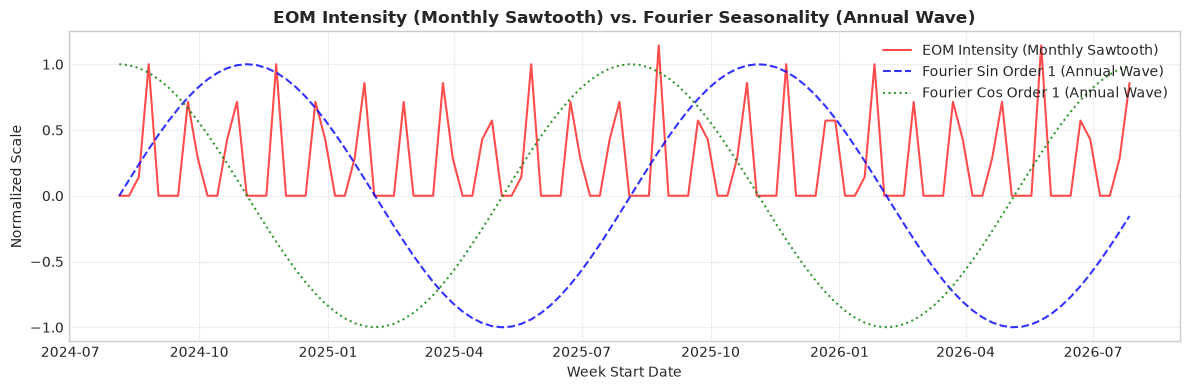

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_model['week_start'], df_model['eom_intensity'], label='EOM Intensity (Monthly Sawtooth)', color='red', alpha=0.7, linewidth=1.5)
plt.plot(df_model['week_start'], df_model['sin_order1'], label='Fourier Sin Order 1 (Annual Wave)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df_model['week_start'], df_model['cos_order1'], label='Fourier Cos Order 1 (Annual Wave)', color='green', linestyle=':', alpha=0.8)

plt.title("EOM Intensity (Monthly Sawtooth) vs. Fourier Seasonality (Annual Wave)", fontsize=12, fontweight='bold')
plt.xlabel("Week Start Date")
plt.ylabel("Normalized Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Fast Media Pre-Transformation (Fixed Carryover & Saturation)

## Purpose
Pre-transform media spend using domain-informed Geometric Adstock ($\alpha_m$) and Hill Reach curves ($S_m=1, K_m = \text{Median}(X_{\text{adstocked}, m})$) prior to PyMC model sampling.

## Mathematical Formulation
1. **Geometric Adstock Decay**:
   $$X_{t,m}^{\text{adstock}} = \frac{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l \cdot X_{t-l, m}}{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l}$$
2. **Hill Reach Saturation Curve ($S=1$)**:
   $$X^*_{t,m} = \frac{X_{t,m}^{\text{adstock}}}{X_{t,m}^{\text{adstock}} + K_m}$$

## Rationale (Jin et al., 2017)
On $N=104$ weekly observations, estimating non-linear Hill parameters ($K_m, S_m$) inside MCMC creates severe parameter non-identifiability. Pre-computing fixed transformations converts the non-linear sampling problem into a well-conditioned Bayesian Linear Regression, accelerating sampling speed and eliminating divergent transitions.

In [7]:
media_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail'
]

# Domain-informed fixed hyperparameter configuration
fixed_media_config = {
    "fp_digital":        {"alpha": 0.20, "l_max": 3},
    "meta_social":       {"alpha": 0.25, "l_max": 3},
    "digital_video_ott": {"alpha": 0.40, "l_max": 4},
    "broadcast_media":   {"alpha": 0.50, "l_max": 6},
    "print_mail":        {"alpha": 0.60, "l_max": 8},
}

def transform_media_series(df: pd.DataFrame, channels: list, config: dict) -> pd.DataFrame:
    """Applies fixed Geometric Adstock and Reach Saturation (S=1, K=Median Spend)."""
    df_trans = pd.DataFrame(index=df.index)
    
    for col in channels:
        x = df[col].values
        c_mean = x.mean()
        x_norm = x / (c_mean if c_mean > 0 else 1.0)
        
        # 1. Geometric Adstock Carryover
        alpha = config[col]["alpha"]
        l_max = config[col]["l_max"]
        weights = np.power(alpha, np.arange(l_max))
        weights /= weights.sum()
        x_adstocked = np.convolve(x_norm, weights)[:len(x_norm)]
        
        # 2. Reach Saturation Curve (S=1, K set to median adstocked spend)
        k_sat = np.median(x_adstocked) if np.median(x_adstocked) > 0 else 1.0
        x_saturated = x_adstocked / (x_adstocked + k_sat + 1e-8)
        
        df_trans[col] = x_saturated
        
    return df_trans

# Scale Target Variable
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Pre-transform Media Matrix
df_media_transformed = transform_media_series(df_model, media_channels, fixed_media_config)

print("✅ Media spend pre-transformed successfully!")
display(df_media_transformed.head())

✅ Media spend pre-transformed successfully!


,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail
0,0.4324,0.4263,0.0000,0.6015,0.0000
1,0.4734,0.4737,0.0000,0.6936,0.0000
2,0.5119,0.4589,0.0000,0.7587,0.2177
3,0.5220,0.5198,0.0000,0.7550,0.1431
4,0.4915,0.5010,0.0000,0.6064,0.0910


# 8. Production PyMC Bayesian MMM Model Specification & Sampling

## Purpose
Specify and sample the refactored Bayesian MMM using PyMC v5+.

## Model Mathematical Equation
$$\tilde{y}_t = \alpha_0 + \sum_{m=1}^{5} \beta_m X^*_{t,m} + \beta_{\text{inv}} Z_{\text{inv},t} + \beta_{\text{eom}} \cdot \text{EOM}_t + \beta_{\text{macro}} Z_{\text{macro},t} + \sum_{j=1}^{4} \gamma_j F_{j,t} + \epsilon_t$$

## Informative Priors Strategy
* **Baseline Intercept ($\alpha_0$)**: $\text{Normal}(\mu=0.60, \sigma=0.10)$ (~60% baseline sales).
* **Media Coefficients ($\beta_m$)**: $\text{HalfNormal}(\sigma=0.20)$ (Enforces strict non-negativity).
* **End-of-Month Push ($\beta_{\text{eom}}$)**: $\text{Normal}(\mu=0.35, \sigma=0.08)$ (Informed prior capturing Month-End stair-step incentive spikes).
* **Inventory Constraint ($\beta_{\text{inv}}$)**: $\text{HalfNormal}(\sigma=0.15)$ (Positive stock availability effect).
* **Macro Headwind ($\beta_{\text{macro}}$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Fourier Seasonality ($\gamma_j$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Observation Noise ($\epsilon_t$)**: $\text{StudentT}(\nu, \mu, \sigma)$ (Robust likelihood handling outlier vehicle spikes).

In [8]:
with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as mmm_titan:

    # --- Data Containers ---
    media_data = pm.Data("media_data", df_media_transformed[media_channels].values, dims=("obs_id", "channel"))
    fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")
    sales_obs = pm.Data("sales_obs", y_scaled, dims="obs_id")

    # --- Priors ---
    intercept = pm.Normal("intercept", mu=0.60, sigma=0.10)
    beta_channel = pm.HalfNormal("beta_channel", sigma=0.20, dims="channel")
    beta_inv = pm.HalfNormal("beta_inv", sigma=0.15)
    
    # Informed EOM Push Prior (Normal centered at 0.35 lift)
    beta_eom = pm.Normal("beta_eom", mu=0.35, sigma=0.08)
    
    beta_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.10)
    beta_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.10, dims="fourier_term")

    # --- Linear Predictor (mu) ---
    mu = pm.Deterministic(
        "mu",
        intercept 
        + pm.math.dot(media_data, beta_channel) 
        + (beta_inv * inv_data) 
        + (beta_eom * eom_data) 
        + (beta_macro * macro_data) 
        + pm.math.dot(fourier_data, beta_fourier),
        dims="obs_id"
    )

    # --- Robust Student-T Likelihood ---
    nu = pm.Exponential("nu", lam=0.1) + 3
    sigma = pm.Exponential("sigma", lam=1.0)
    
    pm.StudentT("likelihood", nu=nu, mu=mu, sigma=sigma, observed=sales_obs, dims="obs_id")

# --- MCMC Sampling ---
with mmm_titan:
    print("🚀 Sampling Production Titan MMM Model...")
    idata_titan = pm.sample(
        draws=1000, 
        tune=1000, 
        chains=4, 
        target_accept=0.95, 
        random_seed=42
    )
    pm.compute_log_likelihood(idata_titan)
    pm.sample_posterior_predictive(idata_titan, extend_inferencedata=True)

print("✅ Model execution and posterior predictive sampling complete!")

🚀 Sampling Production Titan MMM Model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, nu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


Sampling: [likelihood]


✅ Model execution and posterior predictive sampling complete!


# 9. MCMC Convergence Diagnostics & Predictive Accuracy

## Purpose
Evaluate MCMC sampling health and quantify out-of-sample predictive accuracy in actual vehicle units.

## Diagnostic Benchmarks (Gelman et al., 2013)
1. **Divergent Transitions**: Must be 0.
2. **Gelman-Rubin ($\hat{R}$)**: Must be $\le 1.01$ across all parameters to confirm chain mixing.
3. **Bulk Effective Sample Size (ESS)**: Must be $> 400$ for reliable posterior summaries.
4. **Pareto $k$ Diagnostic (LOO-CV)**: Must be $< 0.7$ for all observations to ensure no individual week acts as an influential outlier.

## Model Accuracy Metrics
* **$R^2$ (Coefficient of Determination)**: $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$
* **MAPE (%)**: Mean Absolute Percentage Error on unscaled weekly vehicle sales.
* **RMSE**: Root Mean Squared Error in vehicle units.

1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
Total Divergent Transitions: 0
✅ No divergences detected. Sampler geometry is healthy.
Max R-hat (Target <= 1.01): 1.002
Min Bulk ESS (Target > 400): 2669.0
🚀 ALL CONVERGENCE CHECKS PASSED!


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.645,0.065,0.54,0.75,3319,2916,1.00,0.0011,0.00094
beta_channel[fp_digital],0.145,0.103,0.016,0.34,2727,1730,1.00,0.0017,0.0015
beta_channel[meta_social],0.106,0.082,0.0086,0.26,3186,1879,1.00,0.0012,0.0015
beta_channel[digital_video_ott],0.072,0.055,0.0064,0.17,3248,2169,1.00,0.00083,0.0008
beta_channel[broadcast_media],0.109,0.071,0.013,0.23,2669,1824,1.00,0.0012,0.00088
beta_channel[print_mail],0.234,0.104,0.069,0.4,2689,1514,1.00,0.0019,0.0016
beta_inv,0.0203,0.0178,0.0013,0.055,3062,1993,1.00,0.00027,0.0003
beta_eom,0.246,0.054,0.16,0.33,5159,3072,1.00,0.00076,0.0009
beta_macro,-0.0594,0.023,-0.096,-0.022,3543,3114,1.00,0.00039,0.00032
sigma,0.2587,0.0237,0.22,0.3,3435,2437,1.00,0.0004,0.00039



2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
Model R-Squared (R²):                     0.1576
Mean Absolute Percentage Error (MAPE):    23.86%
Root Mean Squared Error (RMSE):           3.73 vehicles / week

3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
ELPD LOO: -18.83 (SE: 7.37)
Max Pareto k (Target < 0.7): 0.31
✅ Pareto k values are healthy. Out-of-sample prediction is reliable.


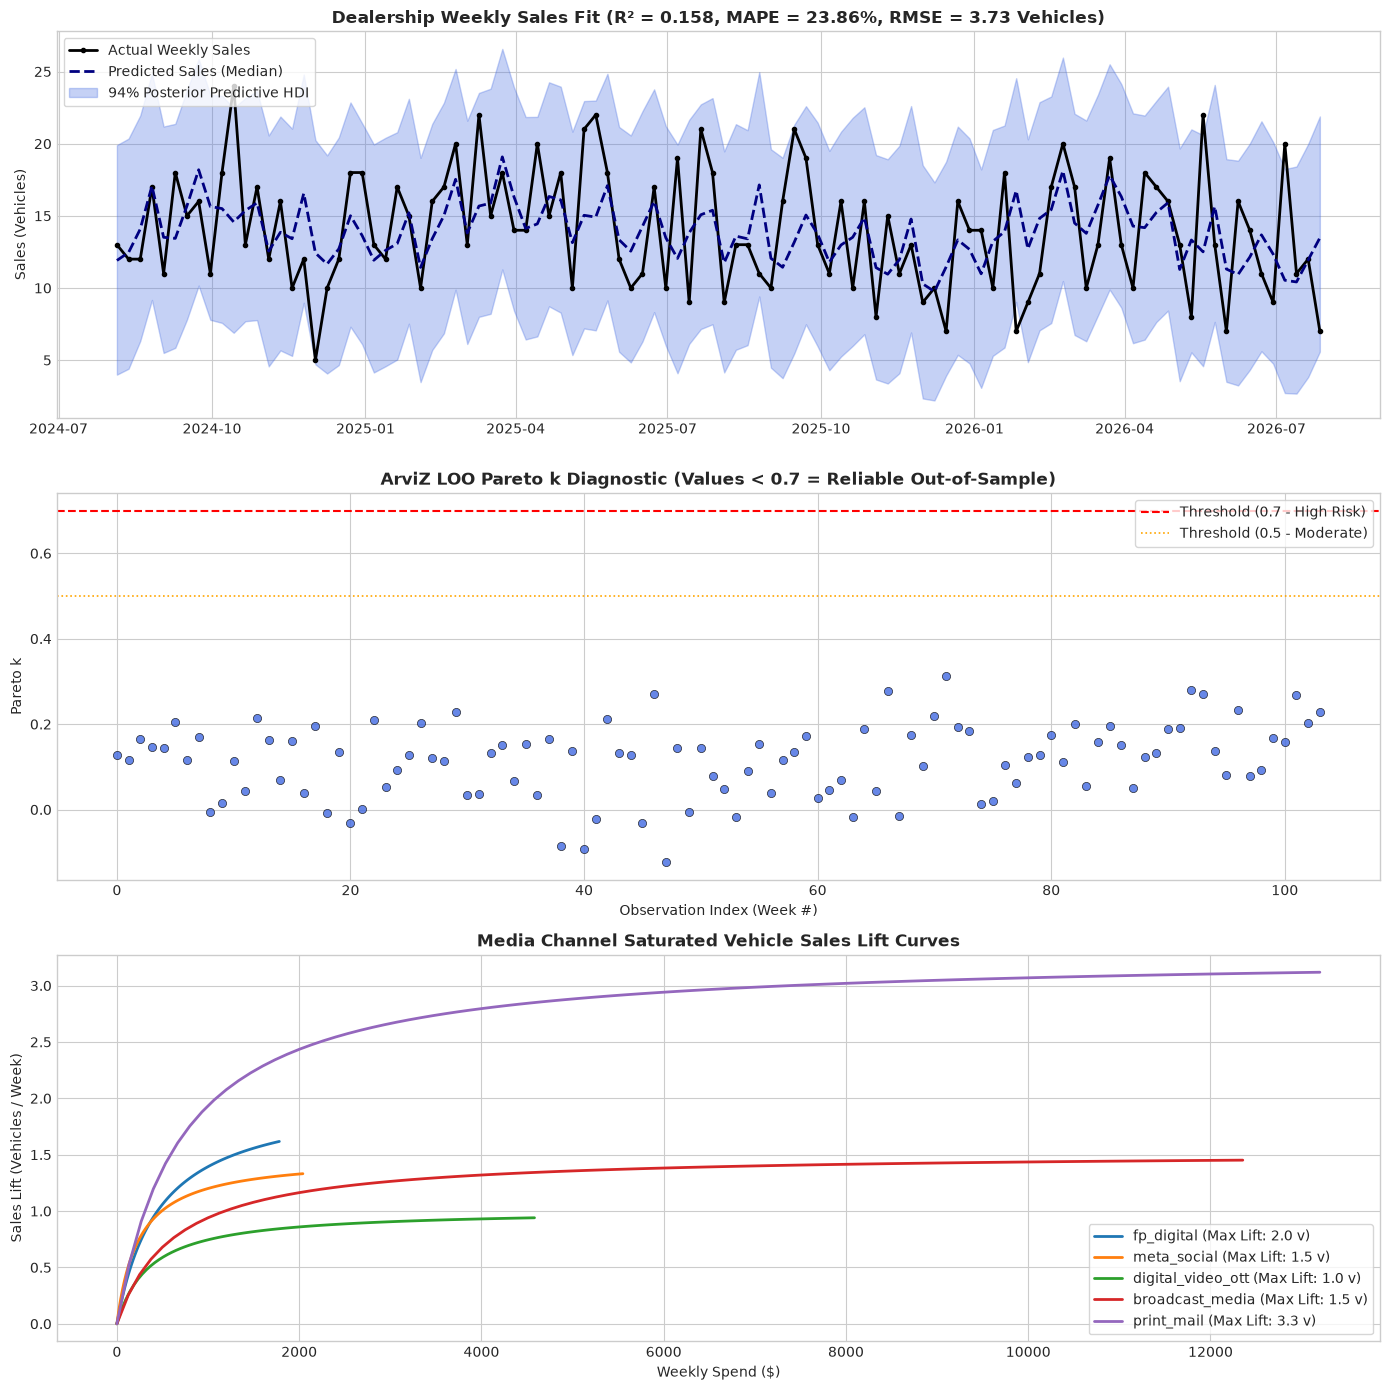

In [12]:
# ==============================================================================
# 1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
# ==============================================================================
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

print("=" * 80)
print("1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK")
print("=" * 80)

# Check Divergences
divergences = idata_titan.sample_stats["divergences"].values.sum()
print(f"Total Divergent Transitions: {divergences}")
if divergences > 0:
    print("⚠️ WARNING: Divergences detected. Consider increasing target_accept.")
else:
    print("✅ No divergences detected. Sampler geometry is healthy.")

# Summary Table
summary_stats = az.summary(
    idata_titan, 
    var_names=["intercept", "beta_channel", "beta_inv", "beta_eom", "beta_macro", "sigma"]
)

max_rhat = summary_stats["r_hat"].max()
min_ess = summary_stats["ess_bulk"].min()

print(f"Max R-hat (Target <= 1.01): {max_rhat:.3f}")
print(f"Min Bulk ESS (Target > 400): {min_ess:.1f}")

if max_rhat <= 1.01 and min_ess >= 400 and divergences == 0:
    print("🚀 ALL CONVERGENCE CHECKS PASSED!")

display(summary_stats)

# ==============================================================================
# 2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
# ==============================================================================
print("\n" + "=" * 80)
print("2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)")
print("=" * 80)

# Version-Safe PPC Sample Extraction (DataArray vs Dataset)
ppc_extracted = az.extract(idata_titan, group="posterior_predictive")

if isinstance(ppc_extracted, xr.Dataset):
    if "likelihood" in ppc_extracted:
        ppc_data = ppc_extracted["likelihood"].values
    else:
        first_var = list(ppc_extracted.data_vars)[0]
        ppc_data = ppc_extracted[first_var].values
elif isinstance(ppc_extracted, xr.DataArray):
    ppc_data = ppc_extracted.values
else:
    ppc_data = np.asarray(ppc_extracted)

if ppc_data.shape[0] == len(df_model):
    ppc_samples = ppc_data.T * sales_mean
else:
    ppc_samples = ppc_data * sales_mean

actual_sales = df_model['sales'].values
pred_median = np.median(ppc_samples, axis=0)
pred_lower = np.percentile(ppc_samples, 3, axis=0)   # 94% HDI Lower
pred_upper = np.percentile(ppc_samples, 97, axis=0)  # 94% HDI Upper

# Accuracy Metrics
mape = np.mean(np.abs((actual_sales - pred_median) / actual_sales)) * 100
rmse = np.sqrt(np.mean((actual_sales - pred_median) ** 2))

ss_res = np.sum((actual_sales - pred_median) ** 2)
ss_tot = np.sum((actual_sales - actual_sales.mean()) ** 2)
r2 = float(1.0 - (ss_res / ss_tot))

print(f"Model R-Squared (R²):                     {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE):    {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE):           {rmse:.2f} vehicles / week")

# ==============================================================================
# 3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV) - VERSION-SAFE EXTRACTION
# ==============================================================================
print("\n" + "=" * 80)
print("3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)")
print("=" * 80)

loo_res = az.loo(idata_titan)

# Extract ELPD
if hasattr(loo_res, "elpd_loo"):
    elpd_val = float(loo_res.elpd_loo)
elif hasattr(loo_res, "elpd"):
    elpd_val = float(loo_res.elpd)
elif "elpd_loo" in loo_res:
    elpd_val = float(loo_res["elpd_loo"])
else:
    elpd_val = float(loo_res["elpd"])

# Extract Standard Error
if hasattr(loo_res, "se"):
    se_val = float(loo_res.se)
elif hasattr(loo_res, "se_elpd_loo"):
    se_val = float(loo_res.se_elpd_loo)
else:
    se_val = float(loo_res["se"])

# Extract Pareto k Diagnostics
if hasattr(loo_res, "pareto_k"):
    pareto_k_obj = loo_res.pareto_k
elif hasattr(loo_res, "khat"):
    pareto_k_obj = loo_res.khat
else:
    pareto_k_obj = loo_res["pareto_k"]

if hasattr(pareto_k_obj, "values"):
    k_array = pareto_k_obj.values
else:
    k_array = np.asarray(pareto_k_obj)

max_k = float(np.max(k_array))

print(f"ELPD LOO: {elpd_val:.2f} (SE: {se_val:.2f})")
print(f"Max Pareto k (Target < 0.7): {max_k:.2f}")

if max_k < 0.7:
    print("✅ Pareto k values are healthy. Out-of-sample prediction is reliable.")
else:
    print("⚠️ High Pareto k detected. Inspect observations with k > 0.7.")

# ==============================================================================
# 4. 3-PANEL DIAGNOSTIC DASHBOARD
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
dates = pd.to_datetime(df_model['week_start'])

# Panel 1: Actual vs Predicted Sales Time Series
axes[0].plot(dates, actual_sales, color='black', linewidth=2, label='Actual Weekly Sales', marker='o', markersize=3)
axes[0].plot(dates, pred_median, color='navy', linestyle='--', linewidth=2, label='Predicted Sales (Median)')
axes[0].fill_between(dates, pred_lower, pred_upper, color='royalblue', alpha=0.3, label='94% Posterior Predictive HDI')
axes[0].set_title(f"Dealership Weekly Sales Fit (R² = {r2:.3f}, MAPE = {mape:.2f}%, RMSE = {rmse:.2f} Vehicles)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sales (Vehicles)", fontsize=10)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Pareto k Scatter Diagnostic
axes[1].scatter(np.arange(len(k_array)), k_array, alpha=0.8, color='royalblue', edgecolor='black', linewidth=0.5, s=35)
axes[1].axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.7 - High Risk)')
axes[1].axhline(0.5, color='orange', linestyle=':', linewidth=1.2, label='Threshold (0.5 - Moderate)')
axes[1].set_title("ArviZ LOO Pareto k Diagnostic (Values < 0.7 = Reliable Out-of-Sample)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Pareto k", fontsize=10)
axes[1].set_xlabel("Observation Index (Week #)", fontsize=10)
axes[1].legend(loc='upper right', frameon=True)

# Panel 3: Pre-Transformed Saturated Lift Curves
post_means = idata_titan.posterior.mean(dim=["chain", "draw"])
beta_means_veh = post_means["beta_channel"].values * sales_mean

for i, chan in enumerate(media_channels):
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_grid = np.linspace(0, max_spend, 100)
    c_mean = df_model[chan].mean() if df_model[chan].mean() > 0 else 1.0
    
    x_adstocked = x_grid / c_mean
    k_sat = np.median(df_media_transformed[chan]) if np.median(df_media_transformed[chan]) > 0 else 1.0
    
    y_lift = (x_adstocked / (x_adstocked + k_sat + 1e-8)) * beta_means_veh[i]
    axes[2].plot(x_grid, y_lift, label=f"{chan} (Max Lift: {beta_means_veh[i]:.1f} v)", linewidth=2)

axes[2].set_title("Media Channel Saturated Vehicle Sales Lift Curves", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CHANNEL-SPECIFIC CONFIGURATION MATRIX
# ==============================================================================

media_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail'
]

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

# Domain-calibrated hyperparameter & prior specification dictionary
channel_priors_config = {
    "fp_digital": {
        "alpha": 0.20, "l_max": 3, "k_scale": 1.0, "s_slope": 1.0,
        "beta_mu": 0.25, "beta_sigma": 0.08
    },
    "meta_social": {
        "alpha": 0.25, "l_max": 3, "k_scale": 1.0, "s_slope": 1.0,
        "beta_mu": 0.18, "beta_sigma": 0.08
    },
    "digital_video_ott": {
        "alpha": 0.40, "l_max": 4, "k_scale": 1.0, "s_slope": 1.0,
        "beta_mu": 0.12, "beta_sigma": 0.06
    },
    "broadcast_media": {
        "alpha": 0.50, "l_max": 6, "k_scale": 1.0, "s_slope": 1.0,
        "beta_mu": 0.10, "beta_sigma": 0.05
    },
    "print_mail": {
        "alpha": 0.60, "l_max": 8, "k_scale": 1.0, "s_slope": 1.0,
        "beta_mu": 0.15, "beta_sigma": 0.05
    }
}

# ==============================================================================
# 2. FAST MEDIA PRE-TRANSFORMATION FUNCTION
# ==============================================================================

def transform_media_custom_priors(df: pd.DataFrame, channels: list, config: dict) -> pd.DataFrame:
    """Pre-computes Geometric Adstock and Reach Saturation per channel specification."""
    df_trans = pd.DataFrame(index=df.index)
    
    for col in channels:
        x_raw = df[col].values
        c_mean = x_raw.mean() if x_raw.mean() > 0 else 1.0
        x_norm = x_raw / c_mean
        
        # 1. Channel-specific Geometric Adstock
        alpha = config[col]["alpha"]
        l_max = config[col]["l_max"]
        weights = np.power(alpha, np.arange(l_max))
        weights /= weights.sum()
        x_adstocked = np.convolve(x_norm, weights)[:len(x_norm)]
        
        # 2. Channel-specific Reach Saturation (S=1, K_sat = k_scale * Median)
        k_scale = config[col]["k_scale"]
        k_sat = np.median(x_adstocked) * k_scale if np.median(x_adstocked) > 0 else 1.0
        x_saturated = x_adstocked / (x_adstocked + k_sat + 1e-8)
        
        df_trans[col] = x_saturated
        
    return df_trans

# Scale Target Variable
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Generate Pre-Transformed Design Matrix
df_media_transformed = transform_media_custom_priors(df_model, media_channels, channel_priors_config)

# Extract Channel-Specific Prior Arrays for PyMC
prior_mus = np.array([channel_priors_config[c]["beta_mu"] for c in media_channels])
prior_sigmas = np.array([channel_priors_config[c]["beta_sigma"] for c in media_channels])

# ==============================================================================
# 3. PYMC BAYESIAN MODEL DEFINITION WITH CHANNEL-SPECIFIC PRIORS
# ==============================================================================

with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as mmm_titan_custom_priors:

    # --- Data Containers ---
    media_data = pm.Data("media_data", df_media_transformed[media_channels].values, dims=("obs_id", "channel"))
    fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")
    sales_obs = pm.Data("sales_obs", y_scaled, dims="obs_id")

    # --- Baseline Intercept Prior (~60% Baseline Volume) ---
    intercept = pm.Normal("intercept", mu=0.60, sigma=0.10)

    # --- Channel-Specific Truncated Normal Media Betas ---
    beta_channel = pm.TruncatedNormal(
        "beta_channel", 
        mu=prior_mus, 
        sigma=prior_sigmas, 
        lower=0.0, 
        dims="channel"
    )

    # --- Control Priors ---
    beta_inv = pm.HalfNormal("beta_inv", sigma=0.15)
    
    # Informed EOM Push Prior (Normal centered at 0.35 lift)
    beta_eom = pm.Normal("beta_eom", mu=0.35, sigma=0.08)
    
    beta_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.10)
    beta_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.10, dims="fourier_term")

    # --- Linear Predictor ---
    mu = pm.Deterministic(
        "mu",
        intercept 
        + pm.math.dot(media_data, beta_channel) 
        + (beta_inv * inv_data) 
        + (beta_eom * eom_data) 
        + (beta_macro * macro_data) 
        + pm.math.dot(fourier_data, beta_fourier),
        dims="obs_id"
    )

    # --- Robust Student-T Likelihood ---
    nu = pm.Exponential("nu", lam=0.1) + 3
    sigma = pm.Exponential("sigma", lam=1.0)
    
    pm.StudentT("likelihood", nu=nu, mu=mu, sigma=sigma, observed=sales_obs, dims="obs_id")

# ==============================================================================
# 4. MCMC SAMPLING & INFERENCE
# ==============================================================================

with mmm_titan_custom_priors:
    print("🚀 Sampling Titan MMM with Custom Channel-Specific Priors...")
    idata_custom = pm.sample(
        draws=1000, 
        tune=1000, 
        chains=4, 
        target_accept=0.95, 
        random_seed=42
    )
    pm.compute_log_likelihood(idata_custom)
    pm.sample_posterior_predictive(idata_custom, extend_inferencedata=True)

print("✅ Model fit complete!")

🚀 Sampling Titan MMM with Custom Channel-Specific Priors...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, nu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


Sampling: [likelihood]


✅ Model fit complete!


In [16]:
import arviz as az
import matplotlib.pyplot as plt

# Forest plot comparing generic vs custom prior models (ArViZ v1.3.0+ compatible)
az.plot_forest(
    [idata_titan, idata_custom],
    model_names=["Generic HalfNormal", "Custom TruncatedNormal"],
    var_names=["beta_channel", "beta_eom", "intercept"],
    combined=True,
    ci_probs=[0.89],
)

plt.suptitle("Posterior Comparison: Generic vs. Custom Channel Priors (89% HDI)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

IndexError: list index out of range